# RAG System

## Topic: Offensive AI vs Defensive AI in Cybersecurity

### RAG System Workflow

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                           RAG SYSTEM ARCHITECTURE                           │
└─────────────────────────────────────────────────────────────────────────────┘

  ┌──────────────────────┐     ┌──────────────┐      ┌──────────────────────┐
  │   Ingest Documents   │────▶│   Chunker    │────▶│    Hybrid retrieval  │
  │        (PDF)         │     │ (LangChain)  │      │   (Vectors +  BM25)  │
  └──────────────────────┘     └──────────────┘      └──────┬───────────────┘
                                                            │
                                                            │
  ┌──────────────┐     ┌──────────────┐                     │
  │   Ollama     │◀────│  Generator   │◀───────────────────┘
  │ (gemma4:e4b) │     │              │
  └──────────────┘     └──────────────┘
           │
           ▼
  ┌────────────────┐       ┌────────────────────┐
  │     Answer     │─────▶│     Evaluation     │
  │                │       │  (RAGAS + Ollama)  │
  └────────────────┘       └────────────────────┘
```

## Research Questions

**RQ1:** How do different reranking strategies (RRF, Neural, and Hybrid) affect the quality of answers?

**RQ2:** Does RAG actually improve answers vs. pure model generation?

In [1]:
# Setup and Imports
import sys
import os
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path('.').absolute()))

from src.rag_system import RAGSystem
print('RAG System imported successfully')

W0525 14:37:55.189000 15676 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.



RAG System imported successfully


## Initialize RAG System and preload model on ollama

In [2]:
# Initialize RAG system with source directory
SOURCE_DIR = Path('sources')

rag = RAGSystem(source_dir=SOURCE_DIR)
print('RAG System initialized')

# Check Ollama and preload model
from src.ollama_manager import OllamaManager

print("\n=== Ollama Status Check ===")
ollama_mgr = OllamaManager(
    base_url=rag.generator.config.base_url,
    model=rag.generator.config.model
)

status = ollama_mgr.get_status_summary()
if status["ollama_available"]:
    print("✅ Ollama is running")
    print(f"Available models: {status['available_models']}")

    if status["matching_model"]:
        print(f"✅ Model '{status['matching_model']}' is available")
        print(f"\n⏳ Loading model into memory...")
        success, elapsed = ollama_mgr.preload_model(status["matching_model"])
        if success:
            print(f"✅ Model ready ({elapsed:.1f}s)")
            rag.generator.config.model = status["matching_model"]
        else:
            print(f"⚠️ Model may not be fully loaded")
    else:
        print(f"⚠️ Configured model '{status['configured_model']}' not found")
else:
    print("❌ Ollama is NOT running")
    print("   Start with: `ollama serve`")

RAG System initialized

=== Ollama Status Check ===
✅ Ollama is running
Available models: ['nomic-embed-text:latest', 'gemma4:e4b', 'qwen3.5:4b', 'mistrallite:7b', 'mistral-openorca:7b', 'mistral:7b', 'qwen2:7b', 'qwen3:8b', 'qwen2.5:7b', 'llama3:8b', 'llama3.2:3b', 'gemma3:4b', 'gemma:7b', 'gemma2:9b', 'gemini-3-flash-preview:cloud', 'gemini-3-flash-preview:latest', 'llama3.1:8b', 'mistral-nemo:12b']
✅ Model 'gemma4:e4b' is available

⏳ Loading model into memory...
✅ Model ready (0.3s)


### 1. Ingest Documents

- **Load**: PDF files from `sources/` directory → extracts text per page
- **Chunk**: Use `RecursiveCharacterTextSplitter` from `langchain_text_splitters` python library to splits text into ~1500 char chunks with 200 char overlap
- **Index**: 
  - **Vector Store**: `BAAI/bge-large-en-v1.5` embeddings model → FAISS index for semantic search
  - **BM25**: `rank_bm25` python library for keyword matching

Using framework like LangChain ([LangChain AI, 2022](#ref3)) is extremely effective to ingest large cybersecurity resources and process them into smaller, semantically meaningful text segments. Selecting 1,500 characters as maxiumn chunk size provides a balanced approach which small enough to avoid embedding irrelevant information while maintain semantic accuracy without breaking up dense concepts ([Zhao et al., 2025](#ref1); [Blefari et al., 2025](#ref2)).

Dense retrieval uses deep learning models to convert sentences into lists of numbers (vectors). This helps the system understand the actual meaning behind a question instead of just matching words. By using Facebook AI Similarity Search ([FAISS](#ref8)), the system can search through millions of these text pieces very quickly. However, this method can sometimes struggle to find exact words, technical codes, or specific error logs ([Asai et al., 2024](#ref4)).

To fix what dense retrieval misses, using BM25 ([Robertson & Zaragoza, 2009](#ref7)) to catch exact matching words. BM25 is an improved version of basic word counting (TF-IDF). It handles different document lengths and caps scores so repeating a word too many times does not mess up the results. Using the lightweight Python Library `rank_bm25` ([rank_bm25](#ref9)) helps the system catch literal word overlaps, error names, and short technical terms ([Hsu et al., 2025](#ref5); [Karpukhin et al., 2020](#ref6)).

Research proves that using only one search tool can cause the system to miss good documents or pull up wrong ones. As shown by the creators of Dense Passage Retrieval (DPR) ([Karpukhin et al., 2020](#ref6)), mixing exact word scores with deep meaning maps gives much better results than using just one method. Gathering results from both types of search creates a cleaner, highly accurate group of documents that helps the language model give much more reliable answers ([Hsu et al., 2025](#ref5); [Karpukhin et al., 2020](#ref6)).

### Key Components
| Component | File | Purpose |
|-----------|------|---------|
| `chunker.py` | `create_chunks()` | LangChain text splitting |
| `vector_store.py` | `VectorStore` | FAISS + `BAAI/bge-large-en-v1.5` embeddings |
| `bm25_retriever.py` | `BM25Retriever` | BM25 keyword search |

In [3]:
# Ingest and index all documents
stats = rag.ingest_documents(SOURCE_DIR)
print(f"Ingested {stats['documents_loaded']} documents")
print(f"Created {stats['chunks_created']} chunks")
print(f"System stats: {rag.get_stats()}")

Loading cached index for 11 files...
Loading vector index from .rag_index\vectors.faiss...
Loading BM25 index from .rag_index\bm25.json...
Loaded 948 chunks from .rag_index\chunks.json
Ingested 11 documents
Created 946 chunks
System stats: {'indexed': True, 'document_count': 948, 'model': 'gemma4:e4b', 'embedding_model': 'BAAI/bge-large-en-v1.5', 'index_dir': '.rag_index'}


## Evaluation

### 2. Query Pipeline
1. **Embed Query**: Convert user question to embedding vector
2. **Hybrid Retrieval**: 
   - Semantic: Top-50 results from FAISS vector similarity
   - Keyword: Top-50 results from BM25 scoring

3. **Ranking**
   - **RRF Fusion** ([Cormack et al., 2009](#ref10)): Reciprocal Rank Fusion (k=60) combines both ranked lists and get the Top-3 chunks

   $$RRF = \sum \frac{1}{k + rank}$$

   - **Cross-Encoder (Neural Reranking)**: Put the user question and document document chunks from sematic and keyword search into AI at the same time. The AI performs intense, token-by-token attention analysis
   - **Hybrid**: Take Top-10 chunks from RRF then in `Cross-Encoder` use only those chunks with user question
   
3. **Generate**: question + Retrieved chunks → Ollama (gemma4:e4b) → Answer

In this RAG system, I implement a two-stage hybrid retrieval pipeline that balances high recall with deep semantic precision ([Caraman et al., 2026](#ref12)). First, I use Reciprocal Rank Fusion (RRF) ([Cormack et al., 2009](#ref10)) to combine the results from dense vector search and keyword search (BM25). Because these two search methods grade text in completely different ways, we can't simply add their raw scores together. Instead, as [Bruch et al., 2023](#ref11) explain, RRF ignores the complicated raw scores entirely and only looks at a document's position within each list, effectively catching a broad, diverse set of candidates. However, because RRF is blind to the actual content of the documents, I feed its top-ranked candidates into a [Cross-Encoder](#ref13) re-ranking model. The Cross-Encoder performs full cross-attention between the query and text, acting as a high-precision filter that catches deep context and subtle nuances that rank-based aggregation misses before the final context window is generated.

### 3. RAGAS Evaluation Metrics
| Metric | Description |
|--------|-------------|
| **Faithfulness** | Does the answer contain only facts from the context? |
| **Answer Relevancy** | How relevant is the answer to the question? |
| **Context Relevance** | Does contexts address the qurey? |

### Key Components
| Component | File | Purpose |
|-----------|------|---------|
| `hybrid_retriever.py` | `HybridRetriever` | RRF fusion of both |
| `generator.py` | `OllamaGenerator` | Ollama API client |
| `evaluator.py` | `RAGASEvaluator` | RAGAS metrics computation |

In [4]:
# RAGAS Evaluation
from src.test_case import CASES
from src.evaluator import RAGASEvaluator

# Initialize evaluator with RAG system
# rerank_mode include Reciprocal Rank Fusion (rrf), Neural Reranking (neural) and RRF + Neural Reranking (hybrid)
evaluator = RAGASEvaluator(rag, rerank_mode = "rrf")
print("Evaluator initialized")

c:\Users\sam99\AppData\Local\Programs\Python\Python311\Lib\site-packages\instructor\providers\gemini\client.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai  # type: ignore[import-not-found]


Evaluator initialized


In [5]:
# Configure evaluation settings
from src.config import config

print("Evaluation configuration:")
print(f"  Model: {config.eval_llm.model}")
print(f"  Base URL: {config.eval_llm.base_url}")
print(f"  Metrics: {evaluator.metrics}")

Evaluation configuration:
  Model: gemma4:e4b
  Base URL: http://localhost:11434/v1
  Metrics: ['faithfulness', 'answer_relevancy', 'context_relevance']


In [6]:
# Run evaluation on all test cases
results = evaluator.run_batch(CASES)
print(f"Evaluated {len(results)} test cases")

[Evaluator] Starting batch evaluation of 10 cases...
[Evaluator] [1/10] Processing case...
[Evaluator] [1/10] Case complete
[Evaluator] [2/10] Processing case...
[Evaluator] [2/10] Case complete
[Evaluator] [3/10] Processing case...
[Evaluator] [3/10] Case complete
[Evaluator] [4/10] Processing case...
[Evaluator] [4/10] Case complete
[Evaluator] [5/10] Processing case...
[Evaluator] [5/10] Case complete
[Evaluator] [6/10] Processing case...
[Evaluator] [6/10] Case complete
[Evaluator] [7/10] Processing case...
[Evaluator] [7/10] Case complete
[Evaluator] [8/10] Processing case...
[Evaluator] [8/10] Case complete
[Evaluator] [9/10] Processing case...
[Evaluator] [9/10] Case complete
[Evaluator] [10/10] Processing case...
[Evaluator] [10/10] Case complete
[Evaluator] Batch evaluation complete: 10 results
Evaluated 10 test cases


In [7]:
# Display evaluation results
evaluator.print_results(results)
evaluator.save_results(results, "eval_results_rrf.json")


RAGAS EVALUATION RESULTS
Question                                           Faith    Relev    CtxRel  
--------------------------------------------------------------------------------
How does prompt injection manipulate the origin... 1.00    0.76    1.00
  [Answer]: Prompt injection manipulates model behavior by altering the input to exploit vulnerabilities in natu...
  [1] Securing-Agentic-Applications-Guide-1.0.pdf, Page 30 (score: 0.032)
  [2] Securing-Agentic-Applications-Guide-1.0.pdf, Page 66 (score: 0.031)
  [3] OWASP-Top-10-for-Agentic-Applications-2026-12.6-1.pdf, Page 10 (score: 0.030)
What specific security risks are associated wit... 1.00    0.99    1.00
  [Answer]: Specific security risks associated with an AI agent's persistent memory include the possibility of c...
  [1] Securing-Agentic-Applications-Guide-1.0.pdf, Page 31 (score: 0.032)
  [2] OWASP-Top-10-for-Agentic-Applications-2026-12.6-1.pdf, Page 27 (score: 0.027)
  [3] Artificial Intelligence Risk Management Fra

  AVERAGE METRIC SCORES BY RERANKING METHOD
Method  Faithfulness  Answer Relevancy  Context Relevance
   RRF      0.683333          0.773783              0.900
Neural      0.580000          0.821934              0.975
Hybrid      0.683333          0.792816              0.875


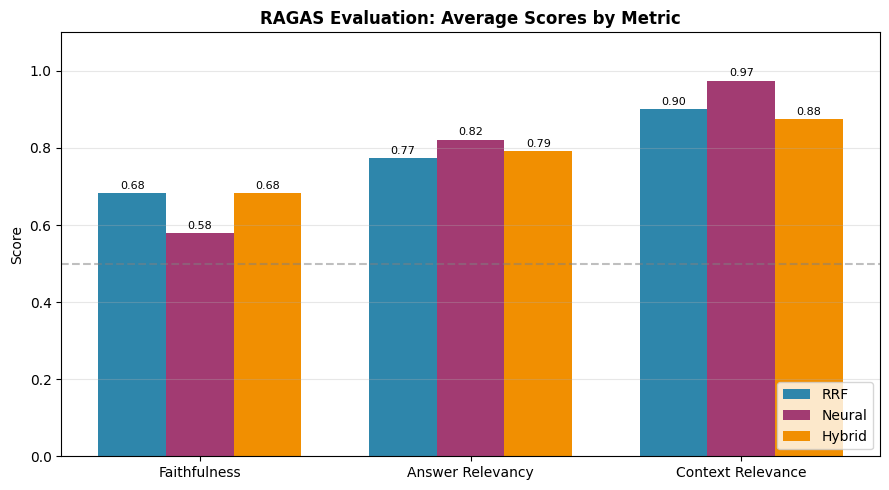


Plot saved: eval_comparison.png


In [10]:
# Compare reranking
import json, pandas as pd, matplotlib.pyplot as plt, numpy as np

files = {'RRF': 'eval_results_rrf.json', 'Neural': 'eval_results_neural.json', 'Hybrid': 'eval_results_hybrid.json'}
metric_keys = ['avg_faithfulness', 'avg_answer_relevancy', 'avg_context_relevance']
metric_labels = ['Faithfulness', 'Answer Relevancy', 'Context Relevance']

# Load results and extract metrics
results = {name: json.load(open(path, encoding='utf-8')) for name, path in files.items()}

# Display comparison table
df = pd.DataFrame({'Method': list(files.keys()), **{
    label: [results[name]['summary'][key] for name in files.keys()]
    for key, label in zip(metric_keys, metric_labels)
}})
print(f"{'='*70}\n  AVERAGE METRIC SCORES BY RERANKING METHOD\n{'='*70}\n{df.to_string(index=False)}\n{'='*70}")

# Plot grouped bar chart (metrics on x-axis, methods as grouped bars)
fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(len(metric_labels)), 0.25
colors = ['#2E86AB', '#A23B72', '#F18F01']
method_names = list(files.keys())
for i, (method, color) in enumerate(zip(method_names, colors)):
    values = [results[method]['summary'][key] for key in metric_keys]
    ax.bar(x + (i - 1) * w, values, w, label=method, color=color)
ax.set_xticks(x), ax.set_xticklabels(metric_labels)
ax.set_ylabel('Score'), ax.set_title('RAGAS Evaluation: Average Scores by Metric', fontweight='bold')
ax.legend(loc='lower right'), ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('eval_comparison.png', dpi=150)
plt.show()
print("\nPlot saved: eval_comparison.png")

## **RQ1:** How do different reranking strategies affect answer quality?

The chart compares three different ways the RAG system finds and ranks documents.

### Reading the Chart
- Bars closer to 1.0 are better
- The gray dashed line shows at 0.5

The Chart shows that `Neural Re-ranking` is the best method for making the AI's answers more accurate and helpful. It achieved a very high `Context Relevance` score of `0.97`, meaning it was incredibly accurate at finding the most relevant background text. This precise context helped the AI create the best answers, leading to the highest `Answer Relevance` score of `0.82`. While the other two methods scored slightly higher in Faithfulness (0.68 vs. Neural Re-ranking's 0.58), they failed to match its performance in formatting the final answer to the user's actual question. This happens because `Neural Re-ranking` reads the actual meaning of the text to bring the most useful details straight to the top, giving the AI the exact information it needs to write clear, highly relevant cybersecurity advice.

In [4]:
# Run baseline evaluation (no retrieval)
baseline_results = evaluator.run_baseline_batch(CASES)

[Baseline] Starting baseline evaluation of 10 cases (no retrieval)...
[Baseline] [1/10] Processing case...
[Baseline] [1/10] Case complete
[Baseline] [2/10] Processing case...
[Baseline] [2/10] Case complete
[Baseline] [3/10] Processing case...
[Baseline] [3/10] Case complete
[Baseline] [4/10] Processing case...
[Baseline] [4/10] Case complete
[Baseline] [5/10] Processing case...
[Baseline] [5/10] Case complete
[Baseline] [6/10] Processing case...
[Baseline] [6/10] Case complete
[Baseline] [7/10] Processing case...
[Baseline] [7/10] Case complete
[Baseline] [8/10] Processing case...
[Baseline] [8/10] Case complete
[Baseline] [9/10] Processing case...
[Baseline] [9/10] Case complete
[Baseline] [10/10] Processing case...
[Baseline] [10/10] Case complete
[Baseline] Batch evaluation complete: 10 results


In [5]:
# Display evaluation results
evaluator.print_results(baseline_results)
evaluator.save_results(baseline_results, "baseline_results.json")


RAGAS EVALUATION RESULTS
Question                                           Faith    Relev    CtxRel  
--------------------------------------------------------------------------------
How does prompt injection manipulate the origin... 0.00    0.77    0.00
  [Answer]: Prompt injection is a sophisticated type of vulnerability that does not involve exploiting tradition...
What specific security risks are associated wit... 0.00    0.93    0.00
  [Answer]: The persistent memory of an AI agent—its ability to retain, recall, and integrate context from past ...
If an autonomous AI agent is compromised via pr... 0.00    0.88    0.00
  [Answer]: This is a critical, highly technical question that sits at the intersection of AI safety, LLM securi...
Why do organizations need AI red teaming if the... 0.00    0.83    0.00
  [Answer]: This is one of the most critical questions in modern cybersecurity, and the answer is rooted in the ...
What are two examples of how model misuse can b... 0.00    0.98

In [6]:
# Calculate comparison metric (Answer Relevancy only)
import json

rag_data = json.load(open('eval_results_rrf.json', encoding='utf-8'))
baseline_data = json.load(open('baseline_results.json', encoding='utf-8'))

metric_keys = ['avg_answer_relevancy']
metric_labels = ['Answer Relevancy']

rag_avg_r = rag_data['summary']['avg_answer_relevancy']
base_avg_r = baseline_data['summary']['avg_answer_relevancy']
diff_r = rag_avg_r - base_avg_r

print("\n" + "=" * 70)
print("  RAG vs BASELINE COMPARISON")
print("=" * 70)
print(f"\n{'Metric':<20} {'RAG':<10} {'Baseline':<10} {'Diff':<10} {'Improvement':<15}")
print("-" * 65)
print(f"{'Answer Relevancy':<20} {rag_avg_r:<10.2f} {base_avg_r:<10.2f} {diff_r:+.2f}       {diff_r*100:+.1f}%")
print("=" * 70)


  RAG vs BASELINE COMPARISON

Metric               RAG        Baseline   Diff       Improvement    
-----------------------------------------------------------------
Answer Relevancy     0.77       0.91       -0.13       -13.3%


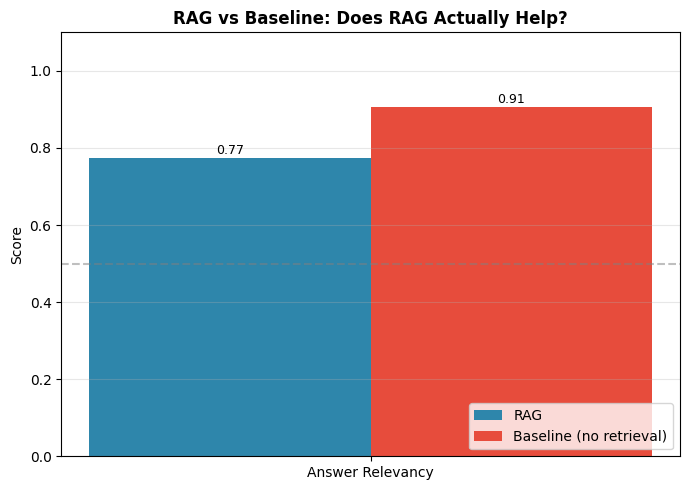


Plot saved: rag_vs_baseline.png


In [8]:
# Plot RAG vs Baseline comparison
import json, matplotlib.pyplot as plt, numpy as np

rag_scores = rag_data['summary']['avg_answer_relevancy']
baseline_scores = baseline_data['summary']['avg_answer_relevancy']

fig, ax = plt.subplots(figsize=(7, 5))
x, w = np.arange(len(metric_labels)), 0.25

ax.bar(x - w/2, rag_scores, w, label='RAG', color='#2E86AB')
ax.bar(x + w/2, baseline_scores, w, label='Baseline (no retrieval)', color='#E74C3C')
ax.set_xticks(x), ax.set_xticklabels(metric_labels)
ax.set_ylabel('Score'), ax.set_title('RAG vs Baseline: Does RAG Actually Help?', fontweight='bold')
ax.legend(loc='lower right'), ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('rag_vs_baseline.png', dpi=150)
plt.show()
print("\nPlot saved: rag_vs_baseline.png")

## **RQ2:** Does RAG actually improve answers vs. pure model generation?

This chart focuses on the difference in avg_answer_relevancy between a RAG system and a pure AI model, revealing that the pure model scores higher. Becasue RAG system must process retrieved documents that sometimes contain extra or confusing details. This added information can distract the AI, causing its final answer to become less focused or slightly off-topic

## References

<a id="ref1">[1]</a>  Zhao, C., De Maria, R., Kumarage, T., Chaudhary, K. S., Agrawal, G., Li, Y., Park, J., Deng, Y., Chen, Y. C., & Liu, H. (2025). CyberBOT: Towards reliable cybersecurity education via ontology-grounded retrieval augmented generation. arXiv preprint arXiv:2504.00389. https://doi.org/10.48550/arxiv.2504.00389

<a id="ref2">[2]</a> Blefari, F., Cosentino, C., Pironti, F. A., Furfaro, A., & Marozzo, F. (2025). CyberRAG: An Agentic RAG cyber attack classification and reporting tool. arXiv. https://doi.org/10.1016/j.future.2025.108186

<a id="ref3">[3]</a> LangChain AI. (2022). LangChain (Version 0.3.7) [Computer software]. GitHub. https://github.com/langchain-ai/langchain

<a id="ref4">[4]</a> Asai, A., Wu, Z., Wang, Y., Sil, A., & Hajishirzi, H. (2024). Self-RAG: Learning to retrieve, generate, and critique through self-reflection. In Proceedings of the International Conference on Learning Representations (ICLR). https://openreview.net/forum?id=hSyW5go0v8

<a id="ref5">[5]</a> Hsu, H.-L., & Tzeng, J. (2025). DAT: Dynamic Alpha Tuning for Hybrid Retrieval in Retrieval-Augmented Generation. arXiv preprint arXiv:2503.23013. https://doi.org/10.48550/arxiv.2503.23013

<a id="ref6">[6]</a> Karpukhin, V., Oğuz, B., Min, S., Lewis, P., Wu, L., Edunov, S., Chen, D., & Yih, W. (2020). Dense Passage Retrieval for Open-Domain Question Answering. In Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing (EMNLP) (pp. 6769–6781). Association for Computational Linguistics.

<a id="ref7">[7]</a> Robertson, S., & Zaragoza, H. (2009). The Probabilistic Relevance Framework: BM25 and Beyond. Foundations and Trends® in Information Retrieval, 3(4), 333–389. https://doi.org/10.1561/1500000019

<a id="ref8">[8]</a> Facebook AI Research. (n.d.). Faiss: A library for efficient similarity search and clustering of dense vectors [Computer software]. GitHub. https://github.com/facebookresearch/faiss

<a id="ref9">[9]</a> Trotman, A. (2019). rank-bm25: A collection of BM25 algorithms in Python [Computer software]. GitHub. https://github.com/dorianbrown/rank_bm25

<a id="ref10">[10]</a> Cormack, G. V., Clarke, C. L. A., & Buettcher, S. (2009). Reciprocal rank fusion outperforms condorcet and individual rank learning methods. In Proceedings of the 32nd International ACM SIGIR Conference on Research and Development in Information Retrieval (pp. 758–759). Association for Computing Machinery. https://doi.org/10.1145/1571941.1572114

<a id="ref11">[11]</a> Bruch, S., Gai, S., & Ingber, A. (2023). An Analysis of Fusion Functions for Hybrid Retrieval. ACM Transactions on Information Systems, 42, 1–35. https://doi.org/10.1145/3596512

<a id="ref12">[12]</a> Caraman, D. M. (2026). Caraman at SemEval-2026 Task 8: Three-Stage Multi-Turn Retrieval with Query Rewriting, Hybrid Search, and Cross-Encoder Reranking. arXiv. https://arxiv.org/pdf/2605.12028

<a id="ref13">[13]</a> Sentence Transformers. (n.d.). Cross-encoder. Hugging Face. Retrieved May 22, 2026, from https://huggingface.co/cross-encoder
